### Market Risk Portfolio Engine

In [3]:
# import packages 
import numpy as np 
import random as rand
import pandas as pd 
import scipy.stats as si
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime
import random
import seaborn as sns

# Objectives: 
# Run Monte Carlo to calculate VaR and ES 
# Use matplotlib and seaborn
# Calculate, measure, and monitor potential financial losses 
# of a investment portfolio due to chanigng market conditions like 
# interest rates, foreign exchange rates, and stock prices.

random.seed(31)

[*********************100%***********************]  2 of 2 completed


Annualized Volatility: 0.1914
Daily Value at Risk (95%): -0.0180


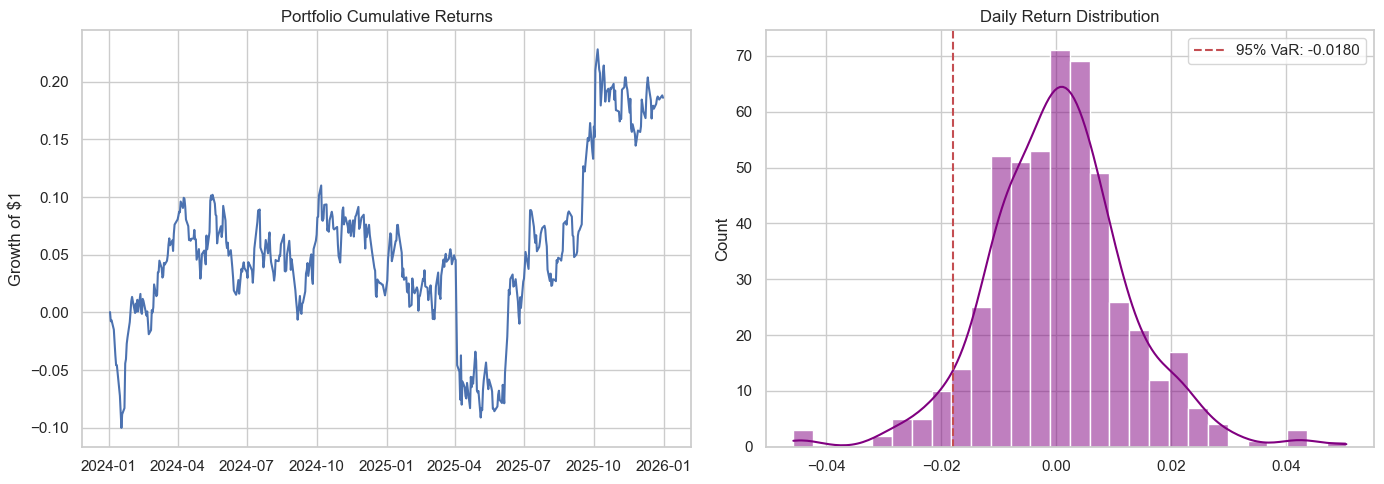

In [8]:
# Download ticker data from yfinance
# I am interested in 'NOC', 'LMT','LLY', 'PFE', 'PLUG','XOM'
tickers_biotech = ["LLY","PFE"]
tickers_defense = ["NOC","LMT"]
tickers_energy = ["PLUG","XOM"]

# Extract adjusted or close prices
data = yf.download(tickers_energy, start="2024-01-01", end="2026-01-01") ['Close']

# Compute daily returns 
returns = data.pct_change().dropna() 

# Define portfolio weights 
w0 = np.random.uniform(0.1,0.5)
w1 = np.random.uniform(0.3,0.7)
weights = np.array([w0, w1]) # Can look into three tickers with three weights

# Portofolio daily returns
portfolio_returns = returns.dot(weights)

# Volatility and risk metrics 
portfolio_volatility = portfolio_returns.std()*np.sqrt(252)
var_95 = np.percentile(portfolio_returns, 5)

print(f"Annualized Volatility: {portfolio_volatility:.4f}")
print(f"Daily Value at Risk (95%): {var_95:.4f}")

# Visualize the results 
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot cumulative portfolio returns
cumulative_returns = (1 + portfolio_returns).cumprod() - 1
axes[0].plot(cumulative_returns.index, cumulative_returns, color="b")
axes[0].set_title("Portfolio Cumulative Returns")
axes[0].set_ylabel("Growth of $1")

# Plot return distribution with VaR line
sns.histplot(portfolio_returns, kde=True, ax=axes[1], color="purple")
axes[1].axvline(
    var_95, color="r", linestyle="--", label=f"95% VaR: {var_95:.4f}"
)
axes[1].set_title("Daily Return Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

Ticker
PLUG    0.000483
XOM     0.000553
dtype: float64 Ticker      PLUG       XOM
Ticker                    
PLUG    0.004564  0.000077
XOM     0.000077  0.000181
Portfolio Value: $100,000.00
95% 1-Day VaR (%): -1.95%
95% 1-Day VaR ($): $1,947.48
95% 1-Day ES (%): -2.45%
95% 1-Day ES ($): $2,451.90


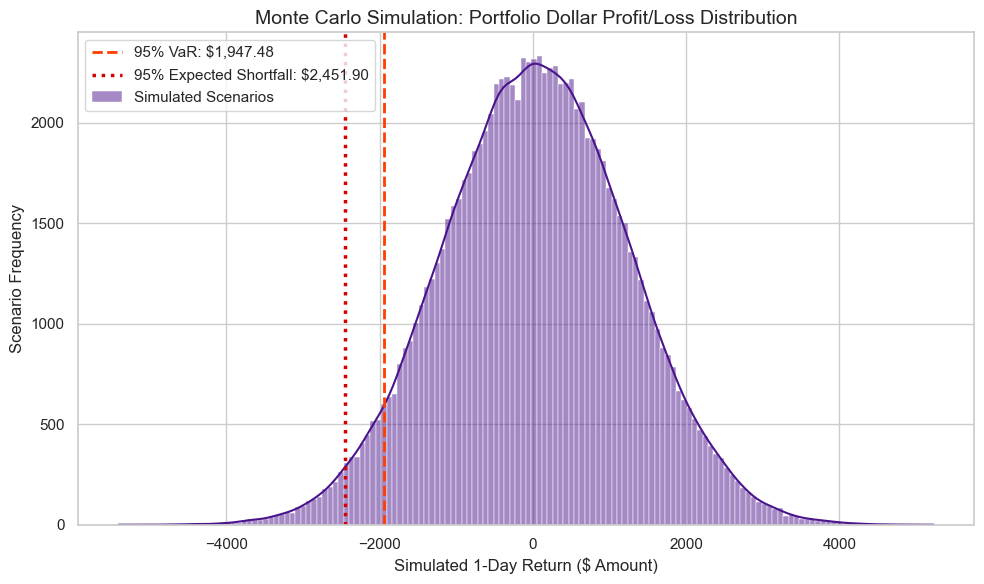

In [18]:
# What if we now implement parametric Monte Carlo using Geometric Brownian motion
initial_portfolio_value = 1E5

# Compute statistical inputs for the simulation 
mean_returns = returns.mean(numeric_only=True)
cov_returns = returns.cov()
print(mean_returns, cov_returns)
# I can compute other statistics if desired

# Monte Carlo Simulation engine - note that I have the random seed generator in the first cell 
num_simulations = 1E5
time_horizon = 1 # 1-day risk horizon 

# Generate multivariate normal daily returns for all assets
simulated_asset_returns = np.random.multivariate_normal( 
    mean_returns, cov_returns, size=(int(time_horizon), int(num_simulations))
)

# Isolate the 1-day simulated step returns
sim_returns_1d = simulated_asset_returns[0, :]

# Calculate simulated portfolio returns
sim_portfolio_returns = np.dot(sim_returns_1d, weights)
sim_portfolio_dollar_losses = initial_portfolio_value*sim_portfolio_returns

# Extract VaR and Expected Shortfall (ES)
confidence_level = 0.95
alpha = 1 - confidence_level  # 0.05 tail threshold

var_pct = np.percentile(sim_portfolio_returns, alpha * 100)
var_dollar = initial_portfolio_value*var_pct

tail_losses_pct = sim_portfolio_returns[sim_portfolio_returns <= var_pct]
es_pct = tail_losses_pct.mean()
es_dollar = initial_portfolio_value*es_pct

# Print Scannable Summary Metrics
print(f"Portfolio Value: ${initial_portfolio_value:,.2f}")
print(f"95% 1-Day VaR (%): {var_pct * 100:.2f}%")
print(f"95% 1-Day VaR ($): ${abs(var_dollar):,.2f}")
print(f"95% 1-Day ES (%): {es_pct * 100:.2f}%")
print(f"95% 1-Day ES ($): ${abs(es_dollar):,.2f}")

# Visualizing results using seaborn
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plot simulated distribution
sns.histplot(
    sim_portfolio_dollar_losses,
    kde=True,
    color="#4A148C",
    label="Simulated Scenarios",
)

# Add Visual Risk Anchors
plt.axvline(
    var_dollar,
    color="#FF3D00",
    linestyle="--",
    linewidth=2,
    label=f"95% VaR: ${abs(var_dollar):,.2f}",
)
plt.axvline(
    es_dollar,
    color="#D50000",
    linestyle=":",
    linewidth=2.5,
    label=f"95% Expected Shortfall: ${abs(es_dollar):,.2f}",
)

# Format Chart
plt.title(
    "Monte Carlo Simulation: Portfolio Dollar Profit/Loss Distribution",
    fontsize=14,
)
plt.xlabel("Simulated 1-Day Return ($ Amount)")
plt.ylabel("Scenario Frequency")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()
